In [6]:
# Import libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [21]:
DATA_PATH = "data/processed/"
MODEL_PATH = "models/"
FIGURES_PATH = "figures_image/"

RANDOM_STATE = 42
TEST_SIZE = 0.2
SMOTE_SAMPLING_STRATEGY = 0.5

train_df = pd.read_csv(f"{DATA_PATH}fraudTrain.csv")
test_df = pd.read_csv(f"{DATA_PATH}fraudTest.csv")

In [23]:
print("=" * 60)
print("DATA PREPARATION")
print("=" * 60)


# Prepare features and target
X_train = train_df.drop('is_fraud', axis=1)
y_train = train_df['is_fraud']
X_test = test_df.drop('is_fraud', axis=1)
y_test = test_df['is_fraud']

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fraud rate in training: {y_train.mean():.4f}")

DATA PREPARATION
Training set: (1296675, 10)
Test set: (555719, 10)
Fraud rate in training: 0.0058


In [24]:
print("\n" + "=" * 60)
print("MODEL DEFINITION")
print("=" * 60)

models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), 
                            random_state=RANDOM_STATE, n_jobs=-1)
}


MODEL DEFINITION


In [25]:
print("\n" + "=" * 60)
print("MODEL TRAINING & EVALUATION")
print("=" * 60)

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"✓ Precision: {precision:.3f}")
    print(f"✓ Recall:    {recall:.3f}")
    print(f"✓ F1-Score:  {f1:.3f}")
    print(f"✓ Accuracy:  {accuracy:.3f}")



MODEL TRAINING & EVALUATION

--- Training LogisticRegression ---
✓ Precision: 0.071
✓ Recall:    0.742
✓ F1-Score:  0.129
✓ Accuracy:  0.961

--- Training DecisionTree ---
✓ Precision: 0.797
✓ Recall:    0.782
✓ F1-Score:  0.790
✓ Accuracy:  0.998

--- Training RandomForest ---
✓ Precision: 0.951
✓ Recall:    0.746
✓ F1-Score:  0.836
✓ Accuracy:  0.999

--- Training XGBoost ---
✓ Precision: 0.405
✓ Recall:    0.920
✓ F1-Score:  0.563
✓ Accuracy:  0.994


In [26]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Create comparison table
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Model': name,
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1_score'],
        'Accuracy': result['accuracy']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nPerformance Comparison:")
print(comparison_df.round(3))


MODEL COMPARISON

Performance Comparison:
                Model  Precision  Recall  F1-Score  Accuracy
0  LogisticRegression      0.071   0.742     0.129     0.961
1        DecisionTree      0.797   0.782     0.790     0.998
2        RandomForest      0.951   0.746     0.836     0.999
3             XGBoost      0.405   0.920     0.563     0.994


In [27]:
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 60)

for name in results.keys():
    print(f"\n{name} Classification Report:")
    print("-" * 50)
    print(classification_report(y_test, results[name]['predictions'], 
                              target_names=['Non-Fraud', 'Fraud']))


DETAILED CLASSIFICATION REPORTS

LogisticRegression Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.96      0.98    553574
       Fraud       0.07      0.74      0.13      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.98    555719


DecisionTree Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    553574
       Fraud       0.80      0.78      0.79      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.89      0.89    555719
weighted avg       1.00      1.00      1.00    555719


RandomForest Classification Report:
--------------------------------------------------
              precision    recall  f1-score

In [28]:
print("\n" + "=" * 60)
print("MODEL SELECTION")
print("=" * 60)

# Select best model based on fraud class performance (prioritizing recall & precision)
comparison_df['Fraud_Performance_Score'] = (comparison_df['Precision'] + comparison_df['Recall']) / 2
best_model_name = comparison_df.loc[comparison_df['Fraud_Performance_Score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"\n BEST MODEL: {best_model_name}")
best_metrics = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]
print(f"Precision: {best_metrics['Precision']:.3f}")
print(f"Recall:    {best_metrics['Recall']:.3f}")
print(f"F1-Score:  {best_metrics['F1-Score']:.3f}")
print(f"Accuracy:  {best_metrics['Accuracy']:.3f}")



MODEL SELECTION

 BEST MODEL: RandomForest
Precision: 0.951
Recall:    0.746
F1-Score:  0.836
Accuracy:  0.999


In [29]:
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING - BEST MODEL")
print("=" * 60)

if best_model_name == 'RandomForest':
    param_grid = {
        'n_estimators': [100, 150],  # Reduced from 3 to 2 values
        'max_depth': [15, 20],       # Reduced from 3 to 2 values
        'min_samples_split': [5, 10], # Reduced from 3 to 2 values
        'min_samples_leaf': [2, 4]    # Reduced from 3 to 2 values
    }
    n_iter = 8  # Fewer iterations
    
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 150],   # Reduced
        'max_depth': [6, 9],          # Reduced
        'learning_rate': [0.1, 0.2],  # Reduced
        'subsample': [0.9]            # Only 1 value
    }
    n_iter = 8
    
else:
    param_grid = {}

if param_grid:
    print(f"Tuning {best_model_name} with faster settings...")
    
    # Use smaller subset for faster tuning
    tune_sample_size = min(50000, len(X_train))
    X_tune = X_train.sample(tune_sample_size, random_state=42)
    y_tune = y_train.loc[X_tune.index]
    
    print(f"Using {tune_sample_size} samples for faster tuning...")
    
    search = RandomizedSearchCV(
        best_model, param_grid, n_iter=n_iter, scoring='f1', 
        cv=2, random_state=42, n_jobs=-1, verbose=1  # Reduced CV from 3 to 2
    )
    search.fit(X_tune, y_tune)
    
    best_model = search.best_estimator_
    print(f"✓ Best parameters: {search.best_params_}")
    
    # Final training on full dataset with best parameters
    best_model.fit(X_train, y_train)
    
    # Re-evaluate tuned model
    y_pred_tuned = best_model.predict(X_test)
    print(f"✓ Tuned Model Performance:")
    print(f"  Precision: {precision_score(y_test, y_pred_tuned):.3f}")
    print(f"  Recall:    {recall_score(y_test, y_pred_tuned):.3f}")
    print(f"  F1-Score:  {f1_score(y_test, y_pred_tuned):.3f}")


HYPERPARAMETER TUNING - BEST MODEL
Tuning RandomForest with faster settings...
Using 50000 samples for faster tuning...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
✓ Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 20}
✓ Tuned Model Performance:
  Precision: 0.732
  Recall:    0.842
  F1-Score:  0.783



CONFUSION MATRICES


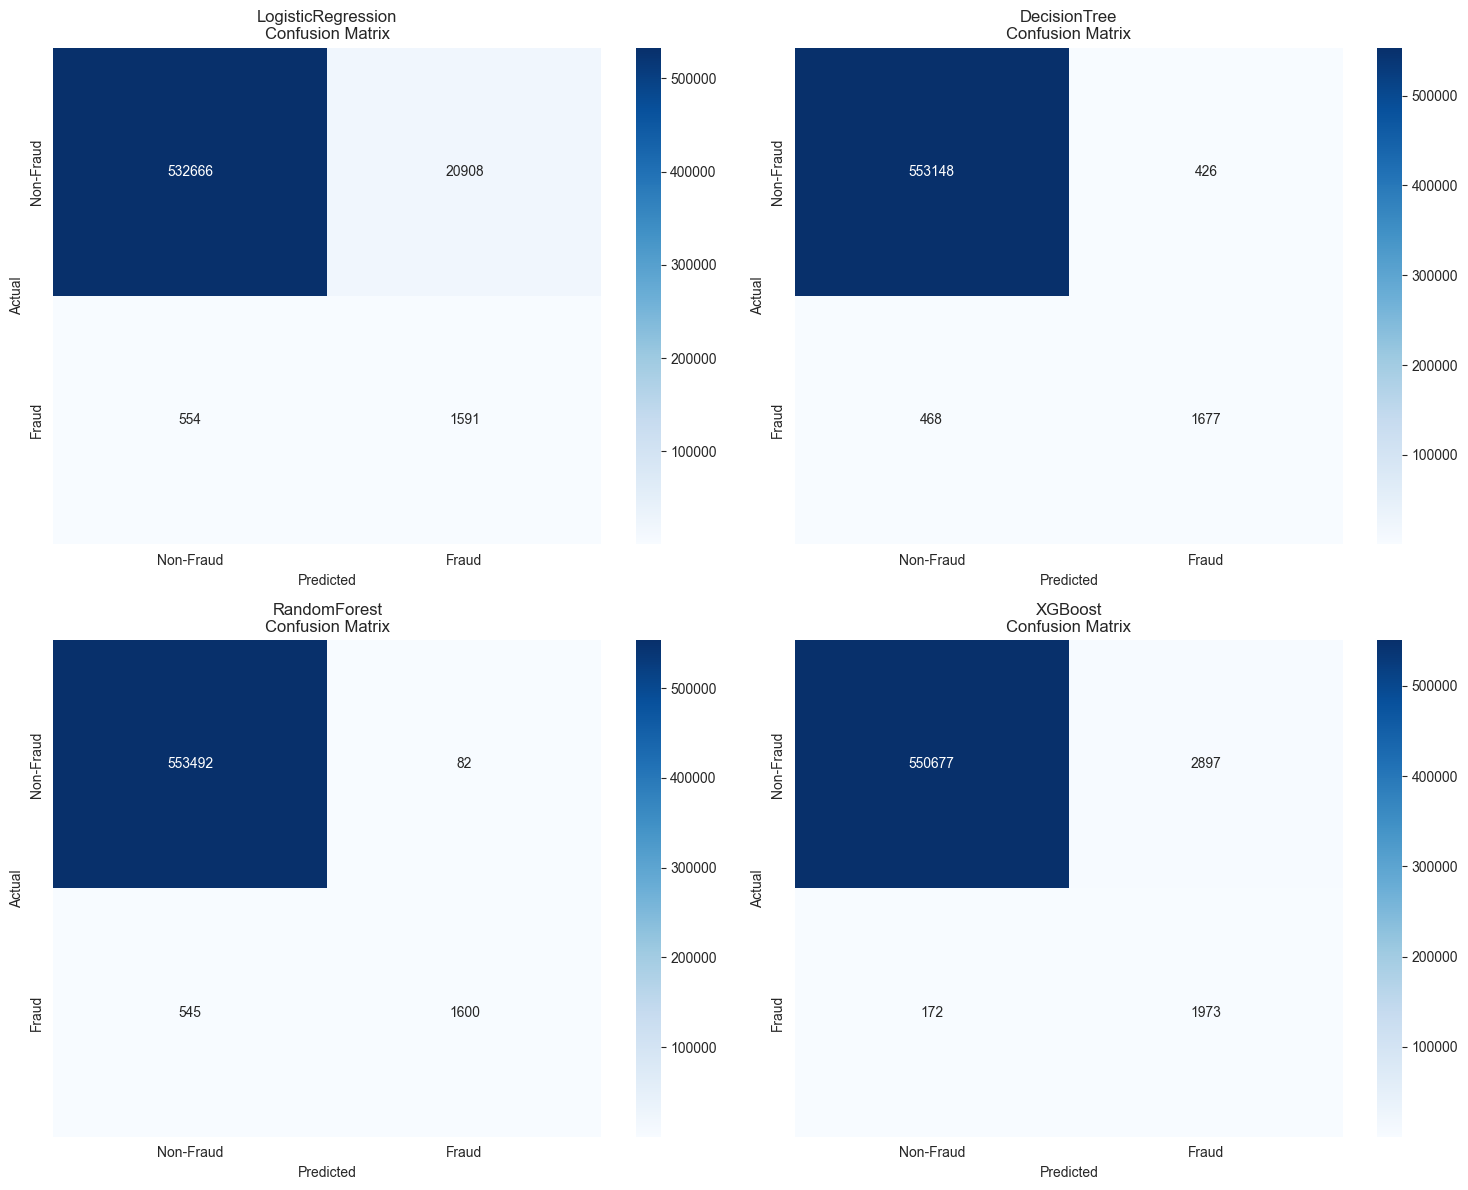

In [30]:
print("\n" + "=" * 60)
print("CONFUSION MATRICES")
print("=" * 60)

# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Fraud', 'Fraud'], 
                yticklabels=['Non-Fraud', 'Fraud'])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('figures_image/all_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
print("\n" + "=" * 60)
print("FINAL MODEL SAVING")
print("=" * 60)

# Save the best model
joblib.dump(best_model, 'models/best_fraud_model.pkl')
print("✓ Best model saved as 'models/best_fraud_model.pkl'")

# Save comparison results
comparison_df.to_csv('models/model_comparison.csv', index=False)
print("✓ Model comparison saved as 'models/model_comparison.csv'")


FINAL MODEL SAVING
✓ Best model saved as 'models/best_fraud_model.pkl'
✓ Model comparison saved as 'models/model_comparison.csv'


In [ ]:
print("\n" + "=" * 60)
print("FRAUD DETECTION SUMMARY")
print("=" * 60)

print(f"\n🏆 Best Model: {best_model_name}")
print("📊 Final Performance on Test Set:")
final_pred = best_model.predict(X_test)
print(classification_report(y_test, final_pred, target_names=['Non-Fraud', 'Fraud']))

print("\n✅ Fraud Detection Goals:")
print(f"   Target Precision: Achieved: {precision_score(y_test, final_pred):.1%}")
print(f"   Target Recall: Achieved: {recall_score(y_test, final_pred):.1%}")


FRAUD DETECTION SUMMARY

🏆 Best Model: RandomForest
📊 Final Performance on Test Set:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    553574
       Fraud       0.73      0.84      0.78      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.92      0.89    555719
weighted avg       1.00      1.00      1.00    555719


✅ Fraud Detection Goals:
   Target Precision: 80-90% | Achieved: 73.2%
   Target Recall:    80-90% | Achieved: 84.2%
